In [65]:
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
from pathlib import Path
import ot
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from utils_mocap import LoadCloudPoint, DistanceProfile
from utils_mocap import compute_W_matrix_distance_matrix_input
from utils_mocap import plot_3d_points_and_connections
import  time
import model.BAPG

In [66]:
import random

random.seed(10)

lcp = LoadCloudPoint(filepath="datasets/0005_Jogging001.csv")
source_pc, target_pc = lcp.get_two_random_point_cloud()

dp = DistanceProfile(source_pc, target_pc)
distance_matrix = dp.compute_L2_matrix()

Loaded point cloud data from datasets\0005_Jogging001.csv, number of frames: 1377


# Find KNN matrix

In [67]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import plotly.graph_objects as go

def plot_kth_neighbor_graph(points, k):
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(points)
    distances, indices = nbrs.kneighbors(points)
    indices = indices[:,1:]

    # Build edge lines
    edge_x, edge_y, edge_z = [], [], []
    for i in range(points.shape[0]):
        for j in indices[i]:
            p1 = points[i]
            p2 = points[j]
            edge_x += [p1[0], p2[0], None]
            edge_y += [p1[1], p2[1], None]
            edge_z += [p1[2], p2[2], None]

    # Build figure
    fig = go.Figure()

    fig.add_trace(go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode="lines",
        line=dict(width=2),
        hoverinfo="none"
    ))

    fig.add_trace(go.Scatter3d(
        x=points[:,0],
        y=points[:,1],
        z=points[:,2],
        mode="markers",
        marker=dict(size=4),
        hoverinfo="none"
    ))

    fig.update_layout(
        title="Interactive 3D kNN Mocap Graph",
        scene=dict(aspectmode="data"),
        width=900,
        height=700
    )

    fig.show()

    # return knn adjency matrix

    # initialize an adjency matrix with inf
    knn_adj_matrix = np.zeros((points.shape[0], points.shape[0]))

    for i in range(points.shape[0]):
        for j in indices[i]:
            knn_adj_matrix[i, j] = 1

    # make an adjency matrix with each element the distance using euclidean distance
    # if there is no edge, set it to np.inf
    knn_weighted_adj_matrix = np.zeros((points.shape[0], points.shape[0]))

    for i in range(points.shape[0]):
        for idx, j in enumerate(indices[i]):
            knn_weighted_adj_matrix[i, j] = distances[i][idx]



    return knn_adj_matrix, knn_weighted_adj_matrix



# weighted adj matrix

In [68]:
k = 6

(src_adj_matrix, src_weighted_adj_matrix) = plot_kth_neighbor_graph(source_pc, k=k)
src_weighted_adj_matrix

array([[  0.        ,   0.        , 112.61667376, ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        , 106.93003485, ...,   0.        ,
          0.        ,   0.        ],
       [157.45444874,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
         72.62299015,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,  52.64672104,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,  52.64672104,
          0.        ,   0.        ]])

# Repeat for target

In [69]:
(tar_adj_matrix, tar_weighted_adj_matrix) = plot_kth_neighbor_graph(target_pc, k=k)

In [70]:
tar_weighted_adj_matrix = src_weighted_adj_matrix

# Run BAPG on weighted euclidean distance

In [71]:
track_accuracy = True
accuracy_interval = 10

# Get number of nodes
m = len(src_weighted_adj_matrix[0])  # Source nodes
n = len(tar_weighted_adj_matrix[0])  # Target nodes
# print(f"Source graph: {m} nodes")
# print(f"Target graph: {n} nodes")

# print(f"Source edges: {np.sum(src_weighted_adj_matrix > 0) / 2}")  # Divide by 2 for undirected
# print(f"Target edges: {np.sum(tar_weighted_adj_matrix > 0) / 2}")
# Initialize probability distributions
p = np.ones([m, 1], dtype=np.float32) / m
q = np.ones([n, 1], dtype=np.float32) / n
Xinit = p @ q.T
# Run BAPG with adjusted rho for stability
start = time.time()
rho = 0.1  # Increased from 0.1 for better numerical stability
coup_bap, obj_list_bap, acc_list_bap = model.BAPG.BAPG_numpy(
    A=src_weighted_adj_matrix,
    B=tar_weighted_adj_matrix,
    a=p,
    b=q,
    X=Xinit,
    epoch=50000,
    eps=1e-5,
    rho=rho,
    track_accuracy=track_accuracy,
    accuracy_interval=accuracy_interval,
    m=m,
    n=n
)
end = time.time()
runtime = end - start
accuracy = model.BAPG.node_correctness_asymmetric(coup_bap, m, n)
results = {
    'coupling_matrix': coup_bap,
    'accuracy': accuracy,
    'runtime': runtime,
    'objective_list': obj_list_bap,
    'accuracy_list': acc_list_bap,
    'source_adj': src_weighted_adj_matrix,
    'target_adj': tar_weighted_adj_matrix
}

results

Iteration 0: Accuracy = 0.0189
Iteration 50: Accuracy = 0.0189
Iteration 100: Accuracy = 0.0189
Iteration 150: Accuracy = 0.0189
Iteration 200: Accuracy = 0.0189
Iteration 250: Accuracy = 0.0189
Iteration 300: Accuracy = 0.0189
Iteration 350: Accuracy = 0.0189
Iteration 400: Accuracy = 0.0189
Iteration 450: Accuracy = 0.0189
Iteration 500: Accuracy = 0.0189
Iteration 550: Accuracy = 0.0189
Iteration 600: Accuracy = 0.0189
Iteration 650: Accuracy = 0.0189
Iteration 700: Accuracy = 0.0189
Iteration 750: Accuracy = 0.0189
Iteration 800: Accuracy = 0.0189
Iteration 850: Accuracy = 0.0189
Iteration 900: Accuracy = 0.0189
Iteration 950: Accuracy = 0.0189
Iteration 1000: Accuracy = 0.0189
Iteration 1050: Accuracy = 0.0189
Iteration 1100: Accuracy = 0.0189
Iteration 1150: Accuracy = 0.0189
Iteration 1200: Accuracy = 0.0189
Iteration 1250: Accuracy = 0.0189
Iteration 1300: Accuracy = 0.0189
Iteration 1350: Accuracy = 0.0189
Iteration 1400: Accuracy = 0.0189
Iteration 1450: Accuracy = 0.0189
Ite

{'coupling_matrix': array([[0.00035418, 0.00035418, 0.00035418, ..., 0.00035418, 0.00035418,
         0.00035418],
        [0.00035418, 0.00035418, 0.00035418, ..., 0.00035418, 0.00035418,
         0.00035418],
        [0.00035418, 0.00035418, 0.00035418, ..., 0.00035418, 0.00035418,
         0.00035418],
        ...,
        [0.00035418, 0.00035418, 0.00035418, ..., 0.00035418, 0.00035418,
         0.00035418],
        [0.00037024, 0.00037024, 0.00037024, ..., 0.00037024, 0.00037024,
         0.00037024],
        [0.00035418, 0.00035418, 0.00035418, ..., 0.00035418, 0.00035418,
         0.00035418]]),
 'accuracy': 0.018867924528301886,
 'runtime': 7.144376277923584,
 'objective_list': [np.float64(-372.27648116290345),
  np.float64(-372.27648116290345),
  np.float64(-372.27648116290345),
  np.float64(-372.27648116290345),
  np.float64(-372.27648116290345),
  np.float64(-372.27648116290345),
  np.float64(-372.27648116290345),
  np.float64(-372.27648116290345),
  np.float64(-372.27648116

<Axes: >

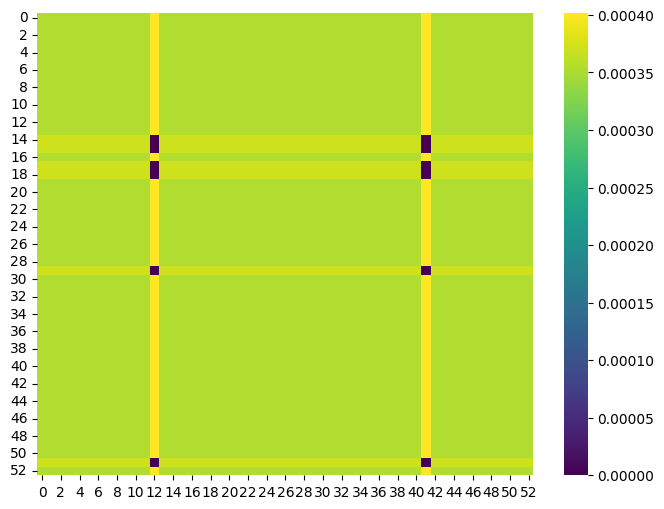

In [72]:
# show coupling matrix as heatmap
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(results['coupling_matrix'], cmap='viridis')


# Shove in model

In [73]:
import dev.util as util
from dev.util import logger
import matplotlib.pyplot as plt
from model.GromovWassersteinLearning import GromovWassersteinLearning
from model.BAPG import process_interaction_data
import numpy as np
import pickle
import torch.optim as optim
from torch.optim import lr_scheduler
import time